<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/Scaler_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement:**
Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit. Provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import regex as re

In [ ]:
!curl -L -o scaler_clustering.csv "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/856/original/scaler_clustering.csv"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23.5M  100 23.5M    0     0  56.1M      0 --:--:-- --:--:-- --:--:-- 56.1M


In [ ]:
df=pd.read_csv('scaler_clustering.csv')

In [ ]:
#shape of dataset.

df.shape

(205843, 7)

In [ ]:
df.describe()

,Unnamed: 0,orgyear,ctc,ctc_updated_year
count,205843.000000,205757.000000,2.058430e+05,205843.000000
mean,103273.941786,2014.882750,2.271685e+06,2019.628231
std,59741.306484,63.571115,1.180091e+07,1.325104
min,0.000000,0.000000,2.000000e+00,2015.000000
25%,51518.500000,2013.000000,5.300000e+05,2019.000000
50%,103151.000000,2016.000000,9.500000e+05,2020.000000
75%,154992.500000,2018.000000,1.700000e+06,2021.000000
max,206922.000000,20165.000000,1.000150e+09,2021.000000


In [ ]:
cols=df.columns
for i in cols:
  print(f'{i}:',df[i].nunique())

Unnamed: 0: 205843
company_hash: 37299
email_hash: 153443
orgyear: 77
ctc: 3360
job_position: 1016
ctc_updated_year: 7


In [ ]:
for i in cols:
  print (f"{i}:", df[i].value_counts())

Unnamed: 0: Unnamed: 0
206922    1
0         1
1         1
206906    1
206905    1
         ..
7         1
6         1
5         1
4         1
3         1
Name: count, Length: 205843, dtype: int64
company_hash: company_hash
nvnv wgzohrnvzwj otqcxwto    8337
xzegojo                      5381
vbvkgz                       3481
zgn vuurxwvmrt vwwghzn       3411
wgszxkvzn                    3240
                             ... 
pzhastbt tdqhzzq                1
ltbontu mj xzctowg              1
tkwqta ucn rna                  1
zhwrtvq ogenfvqt                1
bmq nvqstnxzs                   1
Name: count, Length: 37299, dtype: int64
email_hash: email_hash
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b    10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378     9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee     9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c     9
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d41

In [ ]:
#nulls
df.isnull().sum()

,0
Unnamed: 0,0
company_hash,44
email_hash,0
orgyear,86
ctc,0
job_position,52564
ctc_updated_year,0


In [ ]:
df['email_hash'].value_counts()

,count
email_hash,
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b,10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378,9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee,9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c,9
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065,8
...,...
3def1401b5a8879eeb4a8465663a9c6c66702c85444d7ede5816f58792eb9d41,1
1a304832f202aafe1b12449189a7d5809b8aeb202e19fc15163b0c27c722ff27,1
e3fd08d199c5d805d7b587de710f1ca4e7e686570d07b56c82273a9be943f98b,1


In [ ]:
df['job_position'].value_counts()

,count
job_position,
Backend Engineer,43554
FullStack Engineer,24717
Other,18071
Frontend Engineer,10417
Engineering Leadership,6870
...,...
Business Analyst / Product Owner,1
Principal consultant,1
App Developer,1


In [ ]:
df['orgyear'].value_counts()

###look at the last two values we need to change the format of the year.

,count
orgyear,
2018.0,25256
2019.0,23427
2017.0,23239
2016.0,23043
2015.0,20610
...,...
2204.0,1
1900.0,1
38.0,1


There are invalid year entried like '38', '201', '200'. So thats handeled too.

In [ ]:
df['company_hash']=df['company_hash'].astype(str).str.replace('[^A-Za-z0-9 ]+', '',regex=True).str.strip()
df['job_position']=df['job_position'].astype(str).str.replace('[^A-Za-z0-9 ]+', '',regex=True).str.strip()

In [ ]:
df['ctc_updated_year'] = pd.to_datetime(df['ctc_updated_year'], format='%Y')
df['ctc_updated_year'] = df['ctc_updated_year'].dt.year

In [ ]:
# Convert to numeric
df['orgyear'] = pd.to_numeric(df['orgyear'], errors='coerce')
df['ctc_updated_year'] = pd.to_numeric(df['ctc_updated_year'], errors='coerce')

df.loc[(df['orgyear'] < 1900) | (df['orgyear'] > 2023), 'orgyear'] = np.nan


df['experience'] = df['ctc_updated_year'] - df['orgyear']

df.loc[df['experience'] < 0, 'orgyear'] = np.nan

df['experience'] = df['ctc_updated_year'] - df['orgyear']

print("experience quantiles:\n", df['experience'].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99]))

experience quantiles:
 0.001     0.0
0.010     0.0
0.050     0.0
0.500     4.0
0.950    13.0
0.990    19.0
Name: experience, dtype: float64


In [ ]:
df.shape

(205843, 8)

In [ ]:
#duplicates:

df= df.drop_duplicates(subset=['email_hash','company_hash'], keep='last')



*   Duplicates based on both 'email_hash','company_hash' so that we dont lose valuable infomartion.




In [ ]:
df.shape

(160312, 8)

In [ ]:
df['job_position'] = df['job_position'].replace(['nan', 'NaN', 'NULL', 'Null', ''], np.nan)
df['job_position'].fillna('Unknown',inplace=True)

/tmp/ipython-input-1726626587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['job_position'].fillna('Unknown',inplace=True)


#Outlier Treatment:

Text(0, 0.5, 'Years of Experience (YOE)')

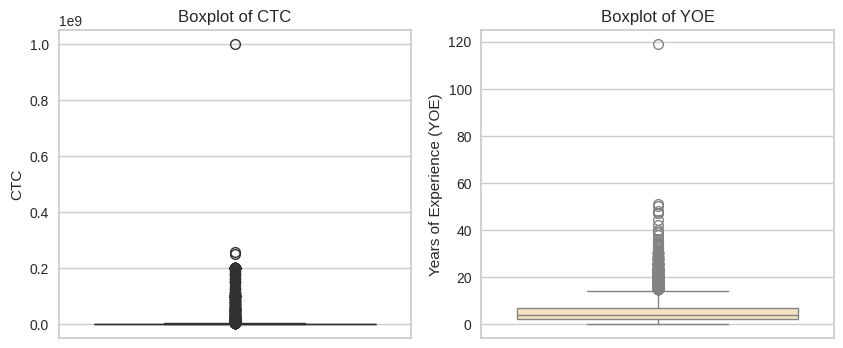

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y='ctc', ax=ax[0])
ax[0].set_title('Boxplot of CTC')
ax[0].set_ylabel('CTC')

sns.boxplot(data=df, y='experience', ax=ax[1],color='moccasin')
ax[1].set_title('Boxplot of YOE')
ax[1].set_ylabel('Years of Experience (YOE)')



*  We can clearly observe outliers in ctc and YOE

*   Outliers can significantly impact the performance and results of clustering algorithms like K-means and hierarchical clustering



In [ ]:
print(df['ctc'].quantile([0.001, 0.01, 0.05]))


0.001      3300.0
0.010     35000.0
0.050    200000.0
Name: ctc, dtype: float64


In [ ]:
lower=df['ctc'].quantile(0.05)
upper=df['ctc'].quantile(0.99)

df['ctc_capped']=df['ctc'].clip(lower,upper)

In [ ]:
print(df['ctc_capped'].quantile([0.001, 0.01, 0.05]))

0.001    200000.0
0.010    200000.0
0.050    200000.0
Name: ctc_capped, dtype: float64


In [ ]:
print(df['experience'].quantile([0.001, 0.01, 0.05]))

0.001    0.0
0.010    0.0
0.050    0.0
Name: experience, dtype: float64


In [ ]:
print(df['ctc_updated_year'].describe())

count    160312.000000
mean       2019.451264
std           1.351100
min        2015.000000
25%        2019.000000
50%        2019.000000
75%        2021.000000
max        2021.000000
Name: ctc_updated_year, dtype: float64


In [ ]:
df['experience'].value_counts()

,count
experience,
2.0,20260
3.0,19924
4.0,18207
1.0,16726
5.0,15244
6.0,11868
0.0,11489
7.0,9324
8.0,6912




*   Majority of values fall between 0 and ~20 years, which is realistic.
*   Values beyond 35 years are rare but clearly incorrect. But there are extreme values too from 40 to all the way to 119 which can be unrealsitic.


*   Based on small business logic and life span of a human capping the values which are unrelasitc to max 35 years only.





In [ ]:
df.loc[df['experience'] > 35, 'experience'] = 35

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
company_hash,0
email_hash,0
orgyear,7890
ctc,0
job_position,0
ctc_updated_year,0
experience,7890
ctc_capped,0


#Imputation:

In [ ]:
##knn imputer
cols=['experience', 'orgyear']
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=5)
df[cols]=imputer.fit_transform(df[cols])
df.isnull().sum()

,0
Unnamed: 0,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0
experience,0
ctc_capped,0


In [ ]:
df1=df.copy()
df1.columns

Index(['Unnamed: 0', 'company_hash', 'email_hash', 'orgyear', 'ctc',
       'job_position', 'ctc_updated_year', 'experience', 'ctc_capped'],
      dtype='object')

In [ ]:
df1.isnull().sum()

,0
Unnamed: 0,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0
experience,0
ctc_capped,0


#Manual Clustering:

In [ ]:
#group by Tier:
df_comp=df1.groupby('company_hash').agg(mean_tier=('ctc','mean'), median_ctc=('ctc','median'),min_ctc=('ctc','min'),max_ctc=('ctc','max'),count_ctc = ('ctc', 'count')).reset_index()
df1=df1.merge(df_comp[['company_hash','mean_tier']],on=['company_hash'])

#group by Desgination:
df_co_jb=df1.groupby(['company_hash','job_position','experience']).agg(mean_designation=('ctc','mean'), median_ctc=('ctc','median'),min_ctc=('ctc','min'),max_ctc=('ctc','max'),count_ctc = ('ctc', 'count')).reset_index()
df1=df1.merge(df_co_jb[['company_hash','job_position','experience','mean_designation']],on=['company_hash','job_position','experience'])

#group by Class:
df_c=df1.groupby(['company_hash','job_position']).agg(mean_class=('ctc','mean'), median_ctc=('ctc','median'),min_ctc=('ctc','min'),max_ctc=('ctc','max'),count_ctc = ('ctc', 'count')).reset_index()
df1=df1.merge(df_c[['company_hash','job_position','mean_class']],on=['company_hash','job_position'])
df1


,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,ctc_capped,mean_tier,mean_designation,mean_class
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020,4.0,1100000,1.115667e+06,1.085000e+06,1.085000e+06
1,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020,5.0,2000000,2.000000e+06,2.000000e+06,2.000000e+06
2,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019,2.0,700000,1.674091e+06,1.298889e+06,1.515000e+06
3,7,vwwtznhqt ntwyzgrgsj,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019.0,400000,Backend Engineer,2019,0.0,400000,8.115000e+05,4.000000e+05,1.243333e+06
4,9,xrbhd,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019.0,360000,Unknown,2019,0.0,360000,3.600000e+05,3.600000e+05,3.600000e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
160307,206918,vuurt xzw,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,220000,Unknown,2019,11.0,220000,1.681941e+06,2.200000e+05,1.681941e+06
160308,206919,husqvawgb,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,500000,Unknown,2020,3.0,500000,2.181064e+06,1.112500e+06,9.841667e+05
160309,206920,vwwgrxnt,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,700000,Unknown,2021,0.0,700000,1.427288e+06,7.666667e+05,1.326333e+06
160310,206921,zgn vuurxwvmrt,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,5100000,Unknown,2019,0.0,5100000,5.556152e+06,4.001141e+06,5.599242e+06


In [ ]:
#Manual Encoding using preset conditions:
def assignment_Tier(x):
  if x['ctc_capped']>x['mean_tier']:
    return 3
  elif x['ctc_capped']==x['mean_tier']:
    return 2
  else:
    return 1

def assignment_Desgination(x):
  if x['ctc_capped']>x['mean_designation']:
    return 3
  elif x['ctc_capped']==x['mean_designation']:
    return 2
  else:
    return 1
def assignment_Class(x):
  if x['ctc_capped']>x['mean_class']:
    return 3
  elif x['ctc_capped']==x['mean_class']:
    return 2
  else:
    return 1

df1['Tier_flag']=df1.apply(assignment_Tier,axis=1)
df1['Designation_flag']=df1.apply(assignment_Desgination,axis=1)
df1['Class_flag']=df1.apply(assignment_Class,axis=1)

In [ ]:
df1.columns

Index(['Unnamed: 0', 'company_hash', 'email_hash', 'orgyear', 'ctc',
       'job_position', 'ctc_updated_year', 'experience', 'ctc_capped',
       'mean_tier', 'mean_designation', 'mean_class', 'Tier_flag',
       'Designation_flag', 'Class_flag'],
      dtype='object')

In [ ]:
col=['ctc','mean_tier','mean_designation','mean_class','Unnamed: 0']
df1.drop(columns=col,inplace=True)

In [ ]:
df1.head()

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,Other,2020,4.0,1100000,1,3,3
1,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,Backend Engineer,2020,5.0,2000000,2,2,2
2,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,Backend Engineer,2019,2.0,700000,1,1,1
3,vwwtznhqt ntwyzgrgsj,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019.0,Backend Engineer,2019,0.0,400000,1,2,1
4,xrbhd,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019.0,Unknown,2019,0.0,360000,2,2,2


###Top 10 employees (earning more than most of the employees in the company) - Tier 1

In [ ]:
df1[df1['Tier_flag']==3].sort_values(by='ctc_capped', ascending=False).head(10)

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
87201,eqtoytq,9a21414cdaa55bd8fae0eca911ccb3ab2a132be8f4e74d...,2019.000000,Frontend Engineer,2019,0.000000,20000000,3,3,3
87155,eqttrvzwtq,dfc026a0ac23f1a48edf83f2ce4c87032930c48023c5f5...,2017.000000,Backend Engineer,2021,4.000000,20000000,3,1,3
34432,ntbtzgo,2c19dfbac43b62d7bc424cc932ecfdb88c224397106ac0...,2019.000000,Unknown,2019,0.000000,20000000,3,1,3
283,ywr ntwyzgrgsxto,319d096c70382ccedb35106fc7e36f61a5129df107cff0...,2014.000000,Backend Engineer,2020,6.000000,20000000,3,3,3
218,lgyz attqt,779c2f874dd5e07ea60f435d2c9ea6cb44ee34d14b401c...,2019.000000,Unknown,2019,0.000000,20000000,3,1,3
89048,vwwtznhqt,065a4758c8b8c8c33928704fa310ea65c1d168ac24f577...,2014.000000,Unknown,2021,7.000000,20000000,3,3,3
89034,vbvkgz,e229403209e6c5c8ade0f6905474cecba91b2f223345ba...,2018.000000,Other,2021,3.000000,20000000,3,3,3
21410,fxuqg rxbxnta,da4198ab6faeec2943bc732b31707223d6de9e548e5fbb...,2020.000000,Other,2021,1.000000,20000000,3,3,3
21354,qxcxsg,5fa750d51093a53523bde615bea27847489c2ff65874bb...,2020.000000,Other,2020,0.000000,20000000,3,1,1
21352,gnytq,86f4a74fe83d88759bad853539a5e272107dd019ac75d5...,2014.659157,FullStack Engineer,2020,4.857868,20000000,3,1,3


###Top 10 employees of data science in each company earning more than their peers - Class 1

In [ ]:
df_mask=df1['job_position'].str.contains('data|machine learning|ml',case=False, na=False)
df_view=df1[df_mask & (df1['Class_flag']==1)]
top_10_each_c=df_view.groupby('company_hash').apply(lambda g: g.nlargest(10, 'ctc_capped')).reset_index(drop=True)
top_10_each_c

/tmp/ipython-input-879446247.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_10_each_c=df_view.groupby('company_hash').apply(lambda g: g.nlargest(10, 'ctc_capped')).reset_index(drop=True)


,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,247vx,c35054c043f6a02da3e6f142fbcb095f8145eb521137ff...,2014.0,Data Scientist,2018,4.0,2150000,3,2,1
1,247vx,5f4b52a1c2539fe2e4b29a8470bc57dbace331b819a0af...,2002.0,Data Scientist,2019,17.0,1440000,1,2,1
2,3p ntwyzgrgsxto,f3b1e96456ad8a7d9cceb3901d763252ea2f56eb2ee7f4...,2013.0,Data Scientist,2019,6.0,1200000,3,2,1
3,3p ntwyzgrgsxto,583a9600d8e74d5f3f6627da6b4ff3c466bf5cfee5ae9f...,2018.0,Data Scientist,2019,1.0,1200000,3,1,1
4,3p ntwyzgrgsxto,89901f32acc07b5ca10c4ee5a9afda6de831cb84a0cbeb...,2019.0,Data Scientist,2019,0.0,1000000,1,2,1
...,...,...,...,...,...,...,...,...,...,...
1794,zxxn ntwyzgrgsxto,6e4b185d9b1fa901e6c408dd226e24dd3eb4d24695084b...,2018.0,Data Scientist,2019,1.0,1500000,3,2,1
1795,zxxn ntwyzgrgsxto rxbxnta,032d8bf5403336d4a5fc081dc72a6eba716990886a02d3...,2014.0,Data Scientist,2021,7.0,1200000,1,2,1
1796,zxzlvwvqn,ce8abe62f0be630a1d02e6bf9105c22d523156207f1bf3...,2018.0,Data Analyst,2019,1.0,630000,1,2,1
1797,zxztrtvuo,10d566c5fca40ffe1d133b79594d071880711ef480da9f...,2017.0,Data Scientist,2019,2.0,1400000,3,2,1


In [ ]:
df['job_position'].unique()

array(['Other', 'Backend Engineer', 'Unknown', 'Data Analyst',
       'Engineering Leadership', 'Data Scientist', 'Frontend Engineer',
       'FullStack Engineer', 'Engineering Intern', 'QA Engineer',
       'iOS Engineer', 'SDET', 'Security Leadership', 'Android Engineer',
       'Support Engineer', 'Research Engineers', 'Product Manager',
       'Devops Engineer', 'Cofounder', 'Product Designer',
       'Backend Architect', 'Database Administrator', 'Program Manager',
       'Senior  Software Engineer', 'Release Engineer', 'Sr EXECUTIVE',
       'Software Engineer Android', 'Owner', 'Senior Data Scientist',
       'Non Coder', 'Software Development Engineer  I', 'SDE3',
       'Principal consultant', 'Architect team lead', 'Software',
       'Instructor', 'Worker', 'Senior Software Engineer Backend',
       'Senior Engineer', 'Toyota', 'Senior Data Engineer',
       'Associate  software  engineer', 'Technical Manager',
       'Senior SDET', 'Software Engineer I', 'Exchange Coordinato

###Bottom 10 employees of data science in each company earning less than their peers - Class 3

In [ ]:
df_mask=df1['job_position'].str.contains('data|machine learning|ml',case=False, na=False)
df_view=df1[df_mask & (df1['Class_flag']==3)]
bot_10_each_c=df_view.groupby('company_hash').apply(lambda g: g.nsmallest(10, 'ctc_capped')).reset_index(drop=True)
bot_10_each_c

/tmp/ipython-input-3602101419.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bot_10_each_c=df_view.groupby('company_hash').apply(lambda g: g.nsmallest(10, 'ctc_capped')).reset_index(drop=True)


,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,247vx,ddd9683a58865398ed934ee7faeb0825e515f2fe3cdaad...,2008.0,Data Scientist,2019,11.0,2500000,3,2,3
1,247vx,9d2537610d57179230806bb77258f63c3134b8fde9aa3a...,2010.0,Data Scientist,2015,5.0,2600000,3,2,3
2,3p ntwyzgrgsxto,af617ba27ec944771314f1c2d739b8208d2b3337800f8f...,2018.0,Data Scientist,2019,1.0,1800000,3,3,3
3,3rgi,a372713f7d18e6f03b5b469cbd1ddb8145c2688597c528...,2014.0,Data Scientist,2019,5.0,1710000,3,2,3
4,aaw,5b9d25111e786a01356529a553c212bce326575af0d800...,2018.0,Data Scientist,2019,1.0,200000,3,3,3
...,...,...,...,...,...,...,...,...,...,...
1643,zxwt xzntqvwnxct ogrhnxgzo,007d0b8b8b80245cba5c804d64d4fa9fd14b4d2e92acdf...,2013.0,Data Scientist,2019,6.0,1130000,1,2,3
1644,zxxn ntwyzgrgsxto,56bc8f0eb4db04e459bf41f51c12b3bbb9c3595d8a172d...,2007.0,Data Scientist,2019,12.0,5500000,3,2,3
1645,zxxn ntwyzgrgsxto rxbxnta,9be05cb8d1f11aa76fb01b9e33ff5633efb82fb22e085f...,2015.0,Data Scientist,2020,5.0,1500000,1,2,3
1646,zxzlvwvqn,19692147647a782458399df4c22010eea8892964835258...,2017.0,Data Analyst,2020,3.0,800000,1,2,3


###Bottom 10 employees (earning less than most of the employees in the company)- Tier 3

In [ ]:
df1[df1['Tier_flag']==3].nsmallest(10,'ctc_capped')

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
65,pvmmvst,9e4e9d8a997b34f9def1039f218c0bd1e3cc9643727013...,2013.000000,SDET,2019,6.000000,200000,3,3,3
73,ojztwnxpo xn wgzohrnxzs ucnrna,e8ac0e7f26df9938d5aee86bfa7a6b6aeab98c016678f3...,2016.000000,FullStack Engineer,2020,4.000000,200000,3,3,3
139,ohzrxet exzvzwxvr ucn rna,a9b9c857bcee49fc5e30f4f10e4c6dfe569dfb230554e6...,2015.000000,Other,2019,4.000000,200000,3,3,3
141,btzngq oxtbtzo mhoxztoo,e95763fc2a0fed3f69f032253923e050cc8a5a07d630aa...,2017.000000,Other,2019,2.000000,200000,3,3,3
143,ayfvzx qhqvr xzegqbvnxgz ojontb,c8383f82ce516a5644457bfa9a3b3af8a890a883be8b77...,2015.000000,Backend Engineer,2019,4.000000,200000,3,3,3
155,am owytzpq,912fd7bd166bba5a3be16fb1c1e6dd2d74c2d07fa1e5f3...,2011.000000,Other,2019,8.000000,200000,3,3,3
171,aqcz xzntrrxstzwt,fa964d7ea5e441f6007cfee535c35771301f5d028d8393...,2018.000000,Backend Engineer,2020,2.000000,200000,3,3,3
177,clnx bhbvmx,42e4a74c2f40b8d30fd2ac8f95f2cf35d540b40f11461e...,2014.659157,Unknown,2019,4.857868,200000,3,3,3
210,xmb wvzvav rvmo,6c95f6eb2b19d0375405cdfb99a420461f432e96cc92d4...,2004.000000,Backend Engineer,2019,15.000000,200000,3,3,3
215,wrxwpcvrrtj ntwyzgrgsxto,184d9238a4a0e52b98f2c044a8c3c6d60f713d1f412758...,2019.000000,Unknown,2019,0.000000,200000,3,3,3


###Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X

In [ ]:
results = {}

for tier in range (1,4):
  view=df1[(df1['Tier_flag']==tier) & ((df1['experience'].isin([5,6,7])))]
  result=view.groupby('company_hash').apply(lambda x: x.nlargest(10,'ctc_capped')).reset_index(drop=True)
  results[f"Tier_{tier}"] = result

/tmp/ipython-input-3618418388.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result=view.groupby('company_hash').apply(lambda x: x.nlargest(10,'ctc_capped')).reset_index(drop=True)
/tmp/ipython-input-3618418388.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result=view.groupby('company_hash').apply(lambda x: x.nlargest(10,'ctc_capped')).reset_index(drop=True)
/tmp/ipython-input-3618418388.py:5: De

In [ ]:
#Tier 1:

results['Tier_1']

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,1bs,70ba1dbf1441301553fc165d293bf11243c242b12f7132...,2012.0,Other,2017,5.0,1500000,1,2,2
1,1bs,ae37b041e3ec19f8600c157cd34d6661674d9dcb90d796...,2013.0,SDET,2020,7.0,1500000,1,2,3
2,1bs,4cb6dc15bb6ec13c9e1698f67fa58d04b5a618a0223539...,2012.0,Frontend Engineer,2018,6.0,1350000,1,2,3
3,1nvm,b133539f72abd982f0ec6128a1c3120533bbd1aa77c583...,2014.0,Frontend Engineer,2020,6.0,1300000,1,2,2
4,1t xzeg ucn rna,7c6890f084f8048684a1459a807c2b302a5573499193fb...,2013.0,Backend Engineer,2019,6.0,1800000,1,2,2
...,...,...,...,...,...,...,...,...,...,...
9791,zxyxrtzn ntwyzgrgsxto,185c3d7ed5e49ef023379c578d78f4f25c6edf2b8c3450...,2014.0,Android Engineer,2019,5.0,800000,1,3,3
9792,zxyxrtzn ntwyzgrgsxto,a6240dd24254a118ee8f5ae213ec78bf9ebd435fc6c6e9...,2013.0,Android Engineer,2019,6.0,800000,1,2,3
9793,zxyxrtzn ntwyzgrgsxto,4a5870ecff35f25d8bf800e765f78816a946af19d78e14...,2013.0,SDET,2019,6.0,600000,1,2,2
9794,zxyxrtzn ntwyzgrgsxto,8db4148d3cdbefbb15d06f09b7ddc2abb32e3a92b1e415...,2012.0,Android Engineer,2017,5.0,200000,1,1,1


In [ ]:
#Tier 2:
results['Tier_2']

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,12ny fgzatq qtotvqwy xzaxv ucn rna,735aeec9e89759154f3fa4f8f99e3da93b821669684298...,2013.0,SDET,2019,6.0,650000,2,2,2
1,1820axsxnvr,7a64650f7c2c73dfe6b1a4c410eb64641e4dacd371bfda...,2014.0,Backend Engineer,2021,7.0,1000000,2,2,2
2,1985,0e0b52e1fa76e607ca155769bbfb978c4dc91b7482df27...,2015.0,Backend Engineer,2020,5.0,1100000,2,2,2
3,1bs ntwyzgrgsxto,757e5f9a0fff2f3adf91cbd4b5453e64827913f6ce0faa...,2013.0,Backend Engineer,2019,6.0,1600000,2,2,2
4,1bs ntwyzgrgsxto,5ec6ab2e3edc8a98335f95115349adea6ab87ff8f63f57...,2013.0,iOS Engineer,2019,6.0,1600000,2,2,2
...,...,...,...,...,...,...,...,...,...,...
6681,zxzlv,b68de52d0c1eb5097d53496996b0804966072cd337b501...,2012.0,Backend Engineer,2019,7.0,5210000,2,2,2
6682,zxzlvbtzngqo,6686ddfddd21c8d8eebbdb7539fc1c2d2c6ff1855d643d...,2015.0,Engineering Leadership,2020,5.0,2000000,2,2,2
6683,zxzvzxjv sqghu,6aeb0a4c55bd87b64c70a963b058a61c29b8654ac86fe9...,2015.0,Engineering Leadership,2020,5.0,1180000,2,2,2
6684,zyco xzaxv,ed0a1202c31bdee343662f5517fc467fb8b96ccaf8e3eb...,2013.0,Other,2019,6.0,500000,2,2,2


In [ ]:
#Tier 3:
results['Tier_3']

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,1bs,350df9243c5c93a9b2a330e7e665c791d9dbe0c7e20209...,2011.0,Unknown,2016,5.0,3300000,3,3,3
1,1bs,bead623eebed2fdb6700e498bd7ad0fe026f4d7b9a2c25...,2012.0,iOS Engineer,2019,7.0,2400000,3,2,1
2,1bs,a58fadbfbc00c007dfe6e5d5891f2dda013eb5cc66552a...,2014.0,FullStack Engineer,2019,5.0,1600000,3,2,3
3,1bs,2b50861d0780b85284d70b0d8d284c6db631fc7462870f...,2014.0,Unknown,2019,5.0,1600000,3,1,3
4,1bs ntwyzgrgsxto ucn rna,b3ee14084e01e9014dfa90d88040318aeda165c49faeec...,2015.0,Unknown,2021,6.0,3500000,3,2,3
...,...,...,...,...,...,...,...,...,...,...
7926,zxztrtvuo,1cd0a52ed52dae24d605d9cdc8536499c10ce62bfb070f...,2014.0,Data Scientist,2021,7.0,2250000,3,2,3
7927,zxztrtvuo,3385dc93ba44f4f1cc237ef4f8e057dab2f693d8961b64...,2013.0,Frontend Engineer,2019,6.0,1800000,3,2,3
7928,zxztrtvuo,16c227291d7c4f151b52599cc15e1ddd6f7e12a694753c...,2015.0,Backend Engineer,2020,5.0,1780000,3,1,1
7929,zxztrtvuo,4a5bc81d942bb281d18a27b6ceb622de65d07a13bc5ab9...,2014.0,Unknown,2020,6.0,1275000,3,1,3


###Top 10 companies (based on their CTC)

In [ ]:
df.groupby('company_hash')['ctc'].mean().nlargest(10) #using the original DF.

,ctc
company_hash,
whmxw rgsxwo uqxcvnt rxbxnta,1.000150e+09
aveegaxr xzntqzvnxgzvr hzxctqoxnj,2.500000e+08
aggovz mgmwvn xzaxv uqxcvnt rxbxnta,2.000000e+08
agyv tdnqvwg,2.000000e+08
ama uqgltwno rxbxnta,2.000000e+08
anaw tduqtoo rxbxnta,2.000000e+08
apvnxv,2.000000e+08
axctqoxexta tztqsj ogrhnxgzo ucn rna,2.000000e+08
bgax uqgltwn rxbxnta,2.000000e+08


In [ ]:
df1.groupby('company_hash')['ctc_capped'].mean().nlargest(10) ##these are capped.

,ctc_capped
company_hash,
2jghqaggq mrxav1 hzxctqoxnj,20000000.0
32255407428,20000000.0
3ow ogrhnxgz,20000000.0
99 mvkvq,20000000.0
agbtonxiht,20000000.0
aggovz mgmwvn xzaxv uqxcvnt rxbxnta,20000000.0
agyv tdnqvwg,20000000.0
ajzvbxnt vootno bvzvstbtzn,20000000.0
ajzvbxw oxszvr,20000000.0


###Top 2 positions in every company (based on their CTC)

In [ ]:
view=df1.groupby(['company_hash','job_position'])['ctc_capped'].mean().reset_index()
view.groupby('company_hash').apply(lambda x: x.nlargest(2,'ctc_capped')).reset_index(drop=True)

/tmp/ipython-input-2677387068.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  view.groupby('company_hash').apply(lambda x: x.nlargest(2,'ctc_capped')).reset_index(drop=True)


,company_hash,job_position,ctc_capped
0,0,Other,200000.0
1,0000,Other,300000.0
2,01 ojztqsj,Frontend Engineer,830000.0
3,01 ojztqsj,Android Engineer,270000.0
4,05mz exzytvrny uqxcvnt rxbxnta,Backend Engineer,1100000.0
...,...,...,...
45321,zz,Other,1370000.0
45322,zz,Unknown,500000.0
45323,zzb ztdnstz vacxogqj ucn rna,Unknown,600000.0
45324,zzgato,Unknown,200000.0


In [ ]:
designation_class_ct = pd.crosstab(df1['Designation_flag'], df1['Class_flag'], normalize='index')
designation_tier_ct = pd.crosstab(df1['Designation_flag'], df1['Tier_flag'], normalize='index')
class_tier_ct = pd.crosstab(df1['Class_flag'], df1['Tier_flag'], normalize='index')

print("Cross-Tabulation between Designation Flag and Class Flag:\n", designation_class_ct)
print("\nCross-Tabulation between Designation Flag and Tier Flag:\n", designation_tier_ct)
print("\nCross-Tabulation between Class Flag and Tier Flag:\n", class_tier_ct)


Cross-Tabulation between Designation Flag and Class Flag:
 Class_flag               1         2         3
Designation_flag                              
1                 0.923683  0.000407  0.075910
2                 0.214167  0.588007  0.197825
3                 0.405033  0.000604  0.594363

Cross-Tabulation between Designation Flag and Tier Flag:
 Tier_flag                1         2         3
Designation_flag                              
1                 0.936918  0.000102  0.062980
2                 0.406249  0.330978  0.262773
3                 0.577768  0.000115  0.422117

Cross-Tabulation between Class Flag and Tier Flag:
 Tier_flag          1         2         3
Class_flag                              
1           0.947794  0.000119  0.052087
2           0.251673  0.562235  0.186093
3           0.353647  0.000152  0.646201


Cross-Tabulation between Designation_Flag and Class_Flag:


*   Designation_Flag 1: 92% of these employees are also in Class_Flag 1.
*   Designation_Flag 2: Majority 58% are in Class_Flag 2.

*   Designation_Flag 3: 64.7% are in Class_Flag 3.
*   (Show how they coincde with Designation ans class).

Cross-Tabulation between Designation_Flag and Tier_Flag:


*   Designation_Flag 1: 93% are in Tier_Flag 1,

*   Designation_Flag 2: Distribution is more spread with notable percentages in all tiers.
*   Designation_Flag 3: 57% in Tier_Flag 1, indicating higher designations are more common in Tier 1 companies.

Cross-Tabulation between Class_Flag and Tier_Flag:


*   Class_Flag 1: 94% are in Tier_Flag 1, indicating lower class levels are predominantly in lower tier companies.

*   Class_Flag 2: 56% in Tier_Flag 2, showing median class levels align with mid tier companies.
*   Class_Flag 3:54% in Tier_Flag 3, indicating higher class levels are mostly in higher tier companies.














#Exploratory Data Analysis:

In [ ]:
df1.head(10)

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.000000,Other,2020,4.000000,1100000,1,3,3
1,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.000000,Backend Engineer,2020,5.000000,2000000,2,2,2
2,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.000000,Backend Engineer,2019,2.000000,700000,1,1,1
3,vwwtznhqt ntwyzgrgsj,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019.000000,Backend Engineer,2019,0.000000,400000,1,2,1
4,xrbhd,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019.000000,Unknown,2019,0.000000,360000,2,2,2
5,wgszxkvzn,134cc4a76a119493d523f1855a3b7106f64287455d5cd4...,2016.000000,Data Analyst,2020,4.000000,440000,1,1,1
6,xznhxn,ebcaf397ef5084e05889a6e9a0c3f96a5c8fb0b16749ce...,2016.000000,Backend Engineer,2019,3.000000,440000,1,1,1
7,pnw xzaxv ucn rna,26ec792de0792706df9beb9a8d37f45d732982e7ea21e2...,2013.000000,Other,2020,7.000000,800000,2,2,2
8,puxn,26b502eb6439ac80bd618a6f7c2b1c640b84c1e64c472c...,2014.659157,Unknown,2019,4.857868,1400000,1,1,3
9,axgz srgmvr,be9363f1468f242f655953b2f088922cb6cad80e62c493...,2006.000000,Engineering Leadership,2019,13.000000,1550000,2,2,2


Text(0.5, 1.0, 'Class Distribution')

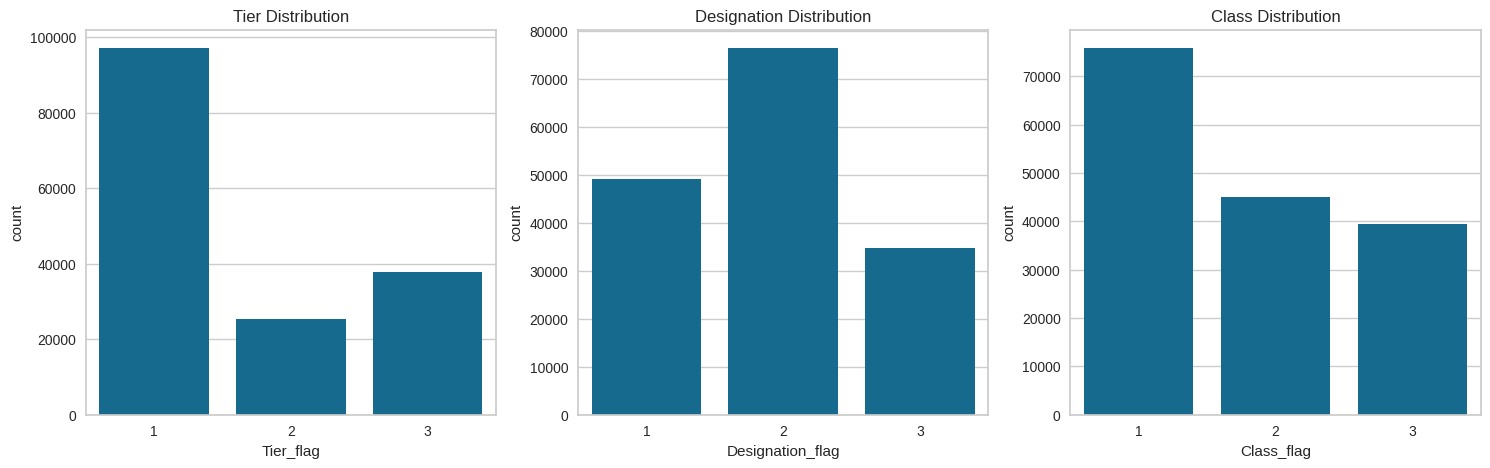

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df1, x='Tier_flag', ax=axes[0])
axes[0].set_title('Tier Distribution')

sns.countplot(data=df1, x='Designation_flag', ax=axes[1])
axes[1].set_title('Designation Distribution')


sns.countplot(data=df1, x='Class_flag', ax=axes[2])
axes[2].set_title('Class Distribution')

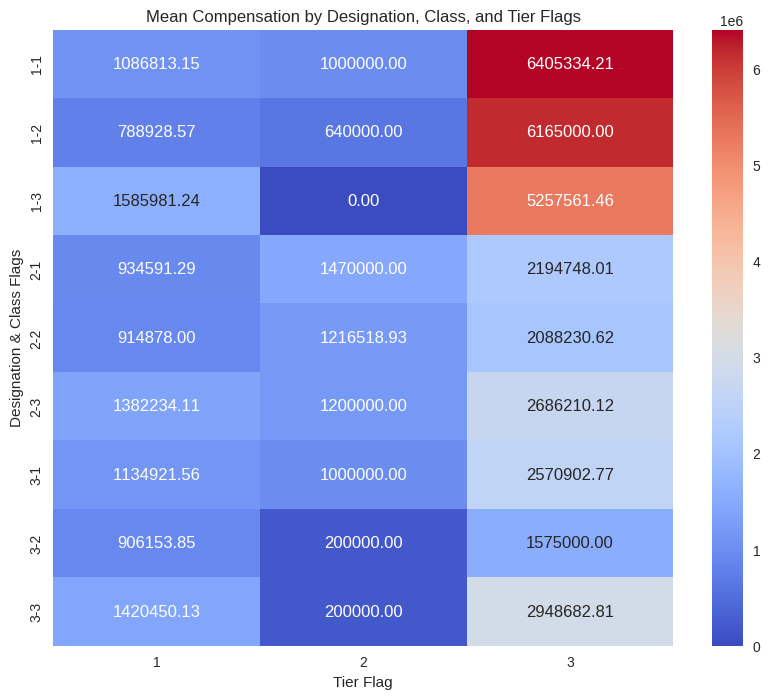

In [ ]:
mean_compensation_flags = df1.groupby(['Designation_flag', 'Class_flag', 'Tier_flag'])['ctc_capped'].mean().unstack().fillna(0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mean_compensation_flags, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mean Compensation by Designation, Class, and Tier Flags')
plt.xlabel('Tier Flag')
plt.ylabel('Designation & Class Flags')
plt.show()



*   Mean CTC in Designation Flag 1 , Class Flag 1 and Tier Flag 1 are highly correlated
*   Followed by mean CTC of D1, C2 and T3.



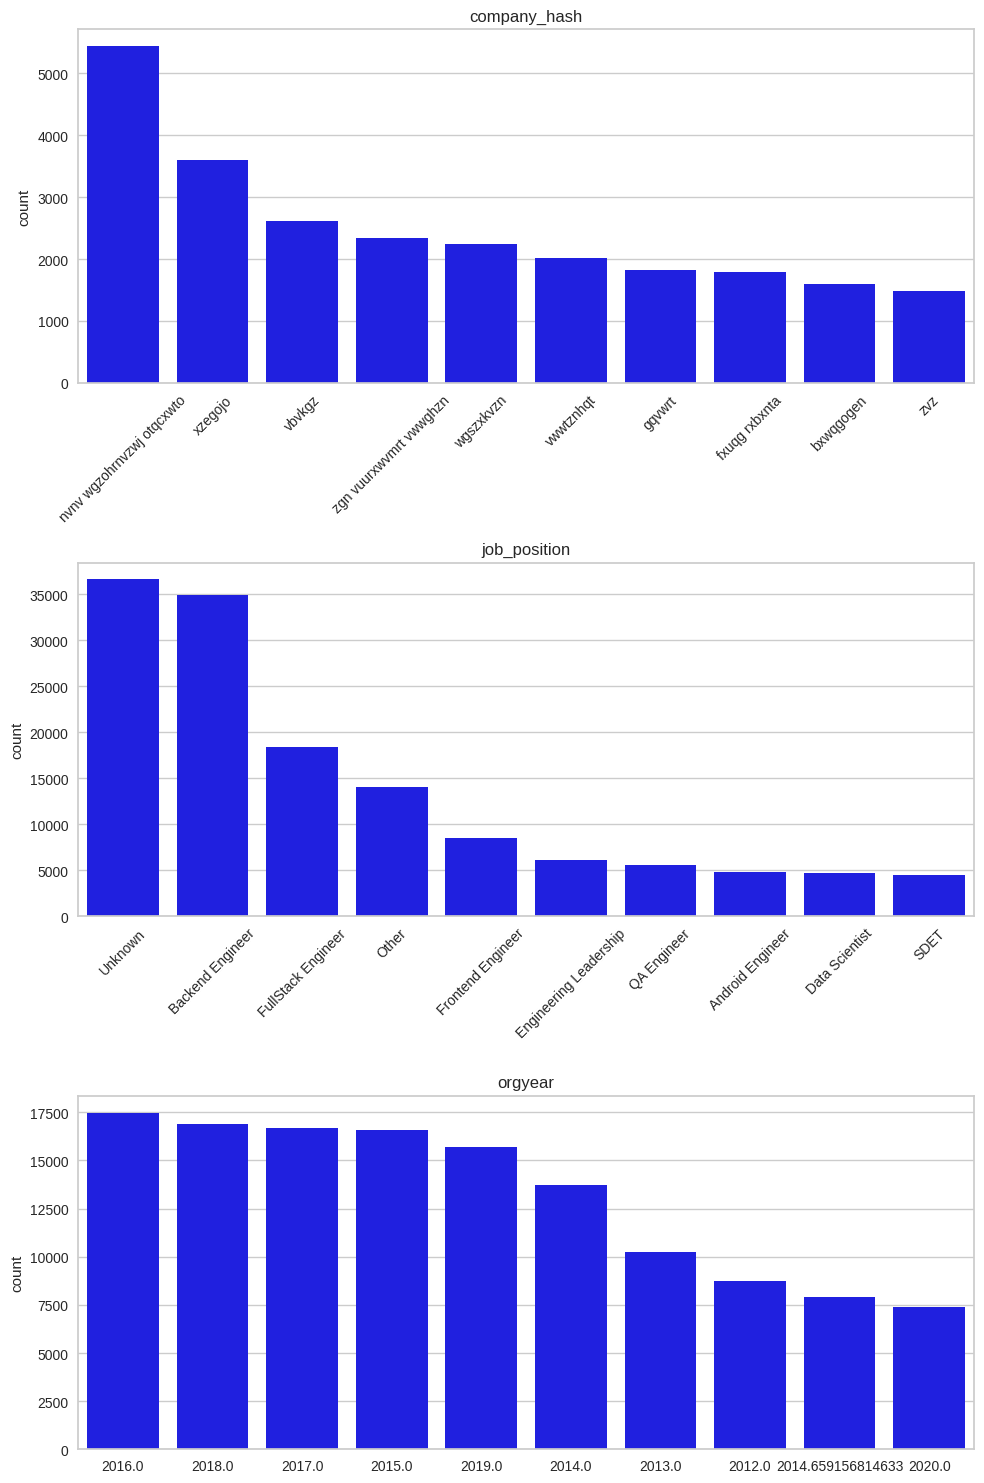

In [ ]:
num_cols= ['ctc_capped','experience']
obj_cols= ['company_hash', 'job_position','orgyear']
plt.figure(figsize=(10, 15))

i = 1
for col in obj_cols:

  top_10 = df1[col].value_counts().nlargest(10)
  top_10_index = top_10.index

  ax = plt.subplot(3, 1, i)
  sns.countplot(x=df1[col], order=top_10_index, color='blue')
  plt.title(f'{col}')
  if i <= 2:
      plt.xticks(rotation=45)

  ax.set_xlabel('')
  i += 1

plt.tight_layout()
plt.show()

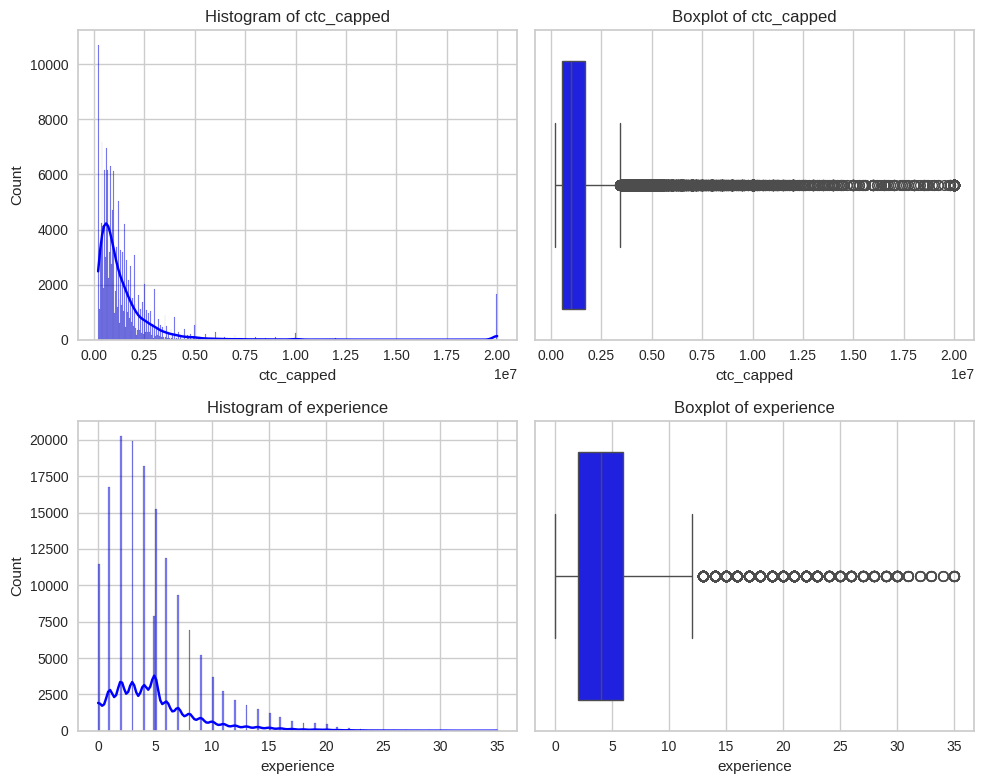

In [ ]:
plt.figure(figsize=(10, 8))


for i, col in enumerate(num_cols):
    # Histogram
    ax1 = plt.subplot(2, 2, 2*i + 1)
    sns.histplot(df1[col], kde=True, color='blue')
    plt.title(f'Histogram of {col}')

    # Boxplot
    ax2 = plt.subplot(2, 2, 2*i + 2)
    sns.boxplot(x=df1[col], color='blue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

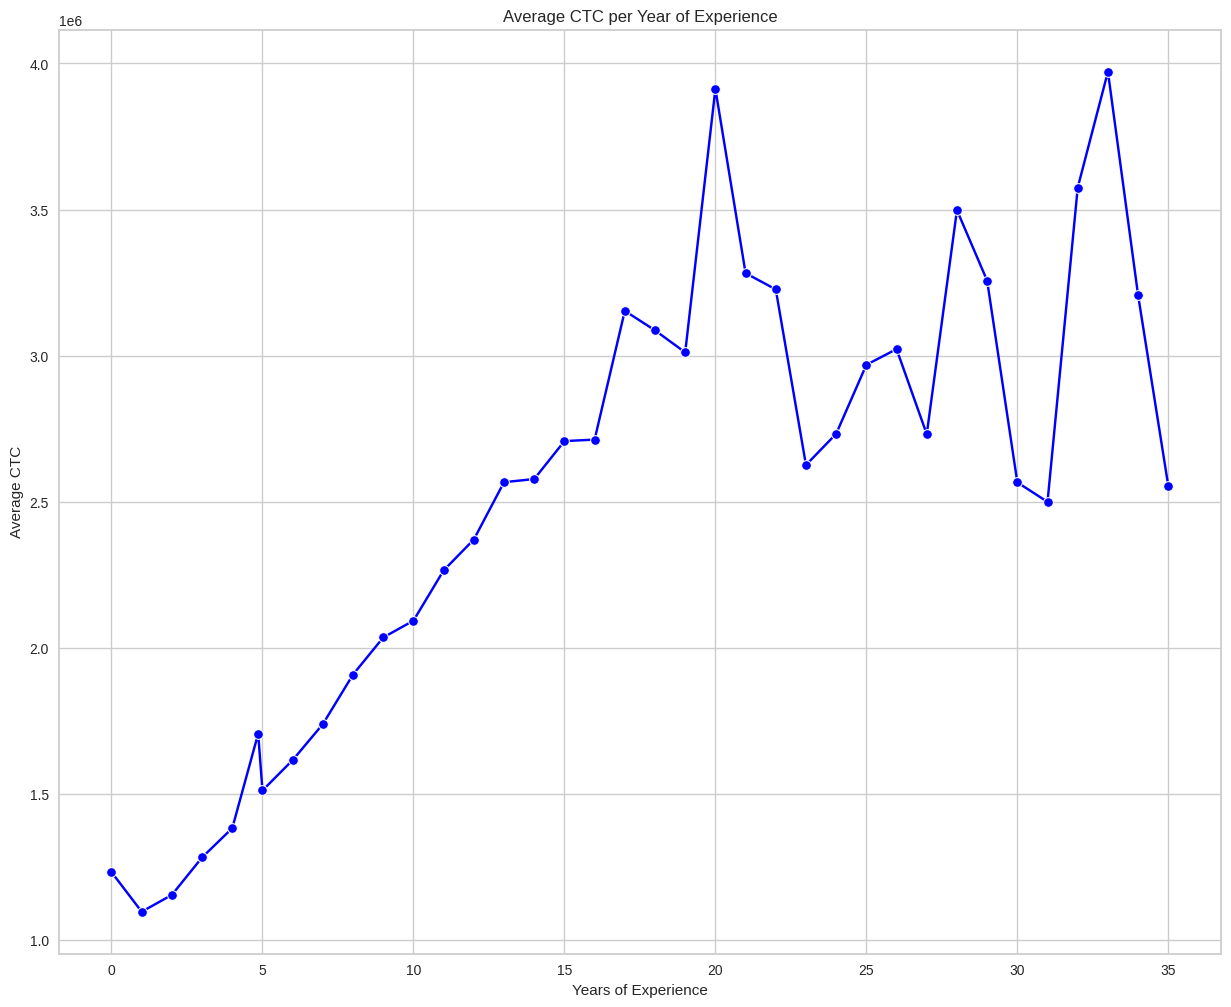

In [ ]:
avg_ctc_per_yoe = df1.groupby('experience')['ctc_capped'].mean().reset_index()
plt.figure(figsize=(15, 12))
sns.lineplot(x='experience', y='ctc_capped', data=avg_ctc_per_yoe, marker='o', color='blue')
plt.title('Average CTC per Year of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average CTC')

plt.show()




*   Average Salary is less for experience between 0-3 years. While Gradually increased post 4 years.
*   Salary peaks at 20 years after gradual increase shows a good coorealtion between experience and salary.


*   After 20 years, the curve becomes less smooth and shows noticeable dips and spikes, experience alone may not be the only factors here, role, industry, begin to matter more.
*   Salary becomes role-driven rather than experience-driven in the late career





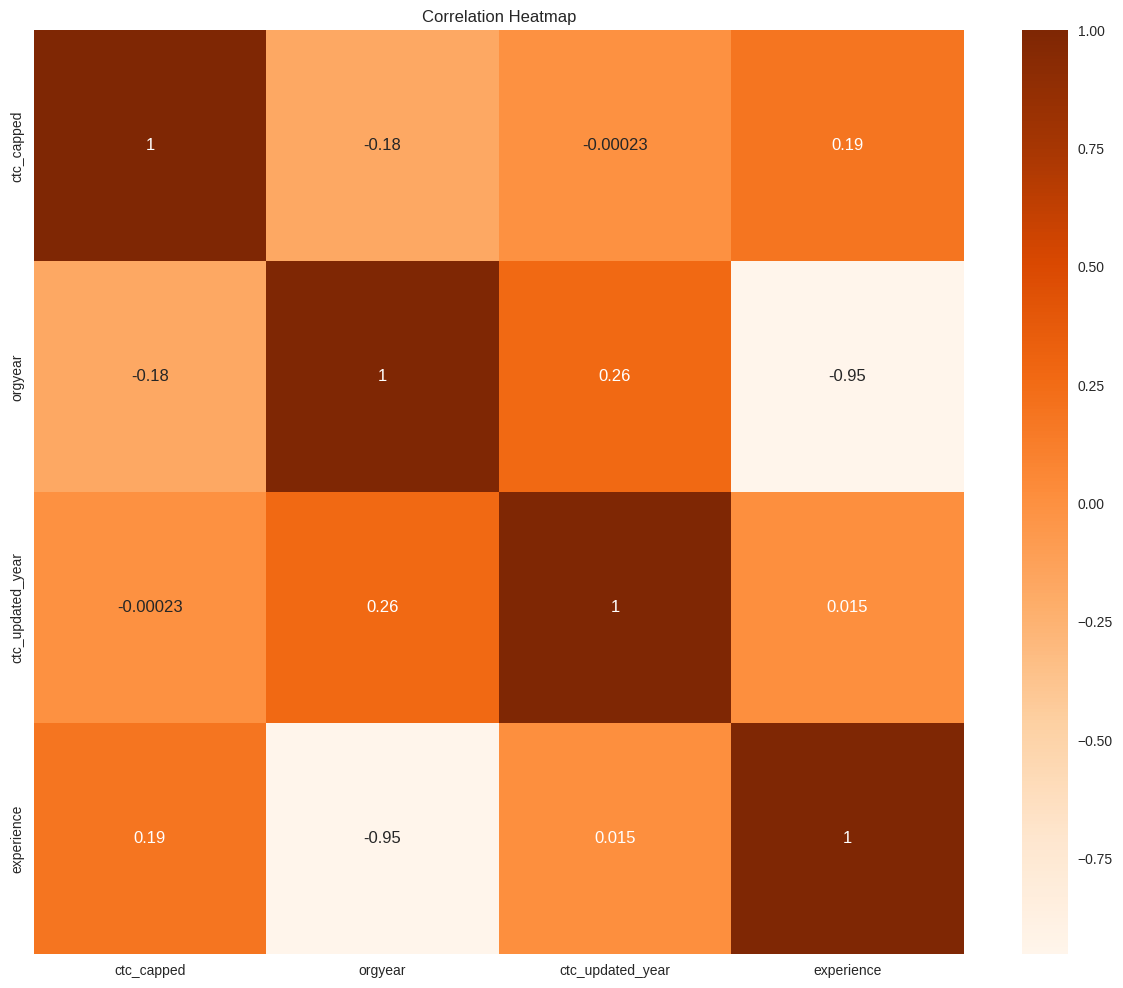

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df1[['ctc_capped' ,'orgyear', 'ctc_updated_year','experience']].corr(), annot=True, cmap='Oranges')
plt.title('Correlation Heatmap')
plt.show()



*   orgyear and ctc_updated_year shown weak positive correlation.
*   Years of Experience and orgyear show strong negative correlation.


*   Years of Experience and CTC show weak positive correaltion







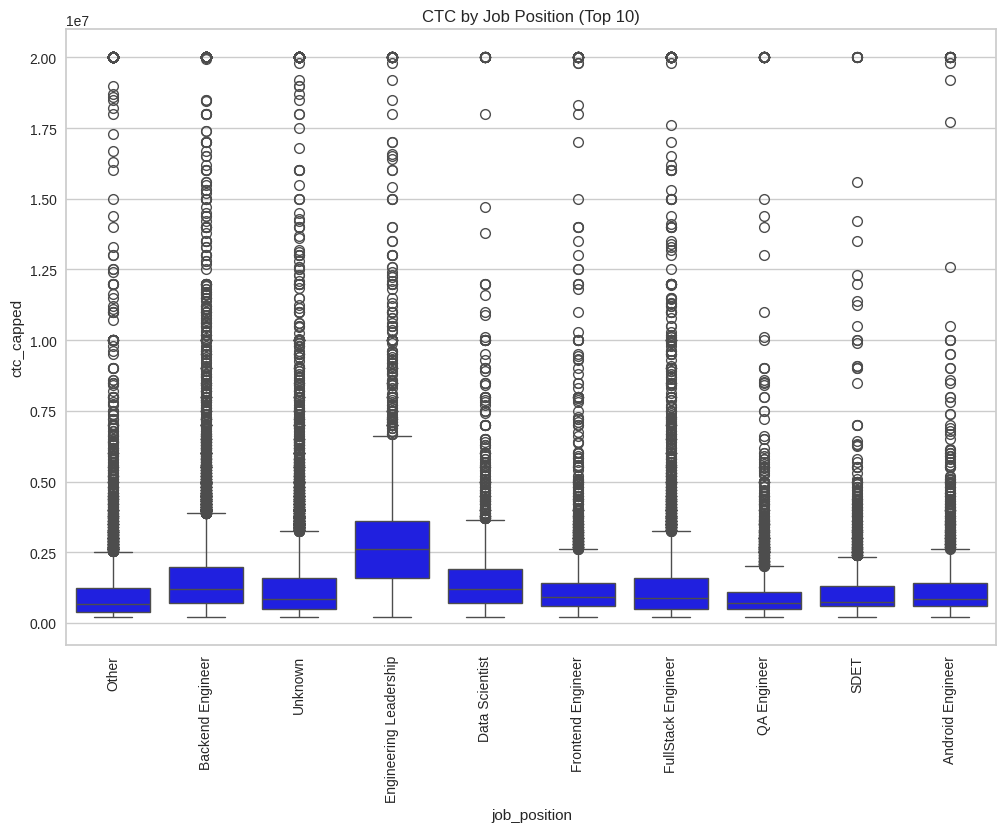

In [ ]:
# Get the top 10 job positions by count
top_10_job_positions = df1['job_position'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df1[df1['job_position'].isin(top_10_job_positions)]

# Plot the box plot for CTC by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_position', y='ctc_capped', data=df_top_10, color='blue')
plt.xticks(rotation=90)
plt.title('CTC by Job Position (Top 10)')
plt.show()



*   CTC is highest for Engineering Leadership followed by Backend Engineer and Data Scientist




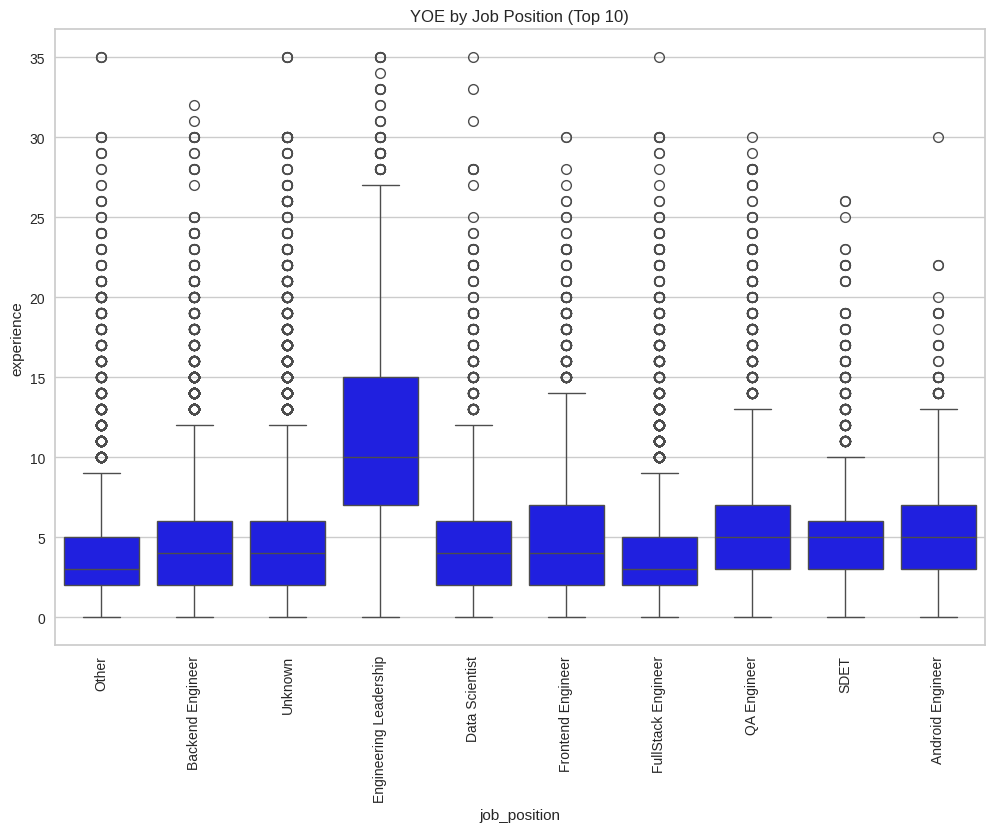

In [ ]:
# Get the top 10 job positions by count
top_10_job_positions = df1['job_position'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df1[df1['job_position'].isin(top_10_job_positions)]

# Plot the box plot for YOE by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_position', y='experience', data=df_top_10,color='blue')
plt.xticks(rotation=90)
plt.title('YOE by Job Position (Top 10)')
plt.show()



*   Years of Experience is highest for Engineering Leadership followed by QA Engineer.



#Clustering (Model Building):

In [ ]:
df1

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,experience,ctc_capped,Tier_flag,Designation_flag,Class_flag
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,Other,2020,4.0,1100000,1,3,3
1,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,Backend Engineer,2020,5.0,2000000,2,2,2
2,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,Backend Engineer,2019,2.0,700000,1,1,1
3,vwwtznhqt ntwyzgrgsj,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019.0,Backend Engineer,2019,0.0,400000,1,2,1
4,xrbhd,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019.0,Unknown,2019,0.0,360000,2,2,2
...,...,...,...,...,...,...,...,...,...,...
160307,vuurt xzw,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,Unknown,2019,11.0,220000,1,2,1
160308,husqvawgb,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,Unknown,2020,3.0,500000,1,1,1
160309,vwwgrxnt,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,Unknown,2021,0.0,700000,1,1,1
160310,zgn vuurxwvmrt,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,Unknown,2019,0.0,5100000,1,3,1


In [ ]:
#Feature building:

df2=df1.drop(columns=['Designation_flag', 'Class_flag', 'Tier_flag'])
email_hash_freq = df2['email_hash'].value_counts().reset_index()
email_hash_freq.columns = ['email_hash', 'no_of_ctc_update']
email_hash_freq

,email_hash,no_of_ctc_update
0,db84980ad197f8eff08b14a3442ff57f6374ea780f2587...,3
1,2baddbd08201dff6cfba7ebd0c72473caa0c55ec94d214...,2
2,6fe9cf62338177fa1966351f572d7be9f04f89f619b0d7...,2
3,8479231faa266fe90ede745b2704d0a8eced011225de91...,2
4,894f6a86450b6e901a30331ca9481651e559a5dbadd904...,2
...,...,...
153438,0a6abca5c729e40efcf87b98aee50786966323fdc37a32...,1
153439,06e23d39f461de3f77c964f58d5e2397004698915a3b06...,1
153440,53314b243b99555f9a21b9a64a41eb72e1275b66f90e1a...,1
153441,499e817011fa047f229a4e4b14757ef8ffc539d6d6236c...,1


In [ ]:
df_merged = pd.merge(df2, email_hash_freq, on='email_hash', how='left')
df_merged.drop(columns=['email_hash','orgyear','ctc_updated_year'],inplace=True)
df_merged

,company_hash,job_position,experience,ctc_capped,no_of_ctc_update
0,atrgxnnt xzaxv,Other,4.0,1100000,2
1,ojzwnvwnxw vx,Backend Engineer,5.0,2000000,2
2,ngpgutaxv,Backend Engineer,2.0,700000,1
3,vwwtznhqt ntwyzgrgsj,Backend Engineer,0.0,400000,1
4,xrbhd,Unknown,0.0,360000,1
...,...,...,...,...,...
160307,vuurt xzw,Unknown,11.0,220000,2
160308,husqvawgb,Unknown,3.0,500000,1
160309,vwwgrxnt,Unknown,0.0,700000,1
160310,zgn vuurxwvmrt,Unknown,0.0,5100000,1


In [ ]:
#encoding:
import category_encoders as ce
encoder = ce.TargetEncoder(cols=['company_hash', 'job_position'])
df_encoded = encoder.fit_transform(df_merged, df_merged['ctc_capped'])
df_encoded

,company_hash,job_position,experience,ctc_capped,no_of_ctc_update
0,1.430328e+06,1.601410e+06,4.0,1100000,2
1,1.595561e+06,1.634246e+06,5.0,2000000,2
2,1.670016e+06,1.634246e+06,2.0,700000,1
3,1.173285e+06,1.634246e+06,0.0,400000,1
4,1.382183e+06,1.392368e+06,0.0,360000,1
...,...,...,...,...,...
160307,1.606083e+06,1.392368e+06,11.0,220000,2
160308,1.604426e+06,1.392368e+06,3.0,500000,1
160309,1.427289e+06,1.392368e+06,0.0,700000,1
160310,2.049230e+06,1.392368e+06,0.0,5100000,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled=pd.DataFrame(df_scaled,columns=df_encoded.columns)
df_scaled

,company_hash,job_position,experience,ctc_capped,no_of_ctc_update
0,-0.253936,0.171914,-0.213950,-0.188102,3.265340
1,0.064701,0.257081,0.035447,0.201012,3.265340
2,0.208281,0.257081,-0.712743,-0.361041,-0.306101
3,-0.749621,0.257081,-1.211537,-0.490746,-0.306101
4,-0.346779,-0.370293,-1.211537,-0.508040,-0.306101
...,...,...,...,...,...
160307,0.084992,-0.370293,1.531829,-0.568569,3.265340
160308,0.081796,-0.370293,-0.463347,-0.447511,-0.306101
160309,-0.259796,-0.370293,-1.211537,-0.361041,-0.306101
160310,0.939562,-0.370293,-1.211537,1.541293,-0.306101


##K-Means:

In [ ]:
#Checking clustering tendency

from sklearn.neighbors import NearestNeighbors
def hopkins_statistic(X):
    X = np.array(X)
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = np.random.random((m, d)) * np.amax(X, axis=0)
    u_distances, _ = nbrs.kneighbors(rand_X, 2, return_distance=True)

    w_distances, _ = nbrs.kneighbors(X[np.random.choice(n, m, replace=False)], 2, return_distance=True)

    u_distances = u_distances[:, 1]
    w_distances = w_distances[:, 1]

    H = (np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances)))
    return H

hopkins_score = hopkins_statistic(df_scaled)
print(f"Hopkins Statistic: {hopkins_score}")

Hopkins Statistic: 0.9869525784243582





*   Hopkins Statistic: 0.9870999880999182 , Data has strong natural cluster. structure.





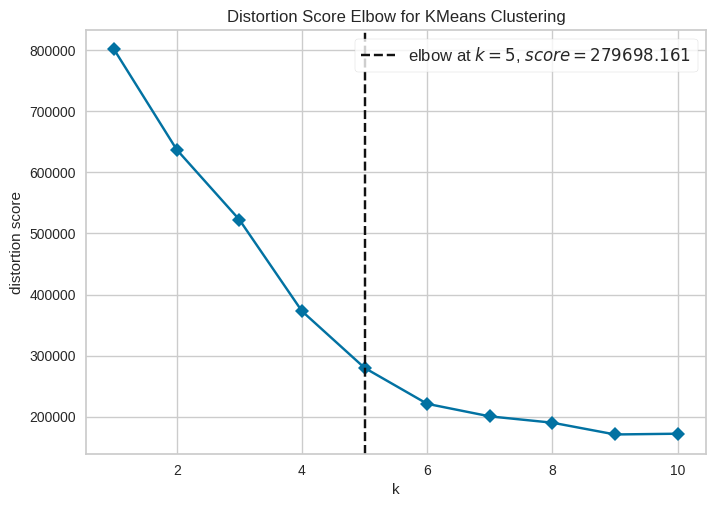

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
#Elbow method
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,11), timings= False)

visualizer.fit(df_scaled)
visualizer.show()

In [ ]:
from sklearn.metrics import silhouette_score
df_sample=df_scaled.sample(n=5000,random_state=42)
sil_scores = {}
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_sample)
    sil_scores[k] = silhouette_score(df_sample, labels)

sil_scores


{2: np.float64(0.49283614566698924),
 3: np.float64(0.4074109384218781),
 4: np.float64(0.47780394493741224),
 5: np.float64(0.41134679777736455),
 6: np.float64(0.39613293768579083),
 7: np.float64(0.2875451954340146)}



*   The elbow point suggests that 6 clusters is a good choice for our data. This is where the inertia starts to decrease at a slower rate, indicating that additional clusters beyond this point don't significantly improve the clustering quality.


*   silhouette Score also confirms the usage of 5 clusters as the ideal clusters needed.






In [ ]:
clusters=5
kmeans = KMeans(n_clusters=clusters, random_state=42)
kmeans.fit(df_scaled)
df_scaled['labels']=kmeans.labels_
df_scaled

,company_hash,job_position,experience,ctc_capped,no_of_ctc_update,labels
0,-0.253936,0.171914,-0.213950,-0.188102,3.265340,2
1,0.064701,0.257081,0.035447,0.201012,3.265340,2
2,0.208281,0.257081,-0.712743,-0.361041,-0.306101,0
3,-0.749621,0.257081,-1.211537,-0.490746,-0.306101,0
4,-0.346779,-0.370293,-1.211537,-0.508040,-0.306101,0
...,...,...,...,...,...,...
160307,0.084992,-0.370293,1.531829,-0.568569,3.265340,2
160308,0.081796,-0.370293,-0.463347,-0.447511,-0.306101,0
160309,-0.259796,-0.370293,-1.211537,-0.361041,-0.306101,0
160310,0.939562,-0.370293,-1.211537,1.541293,-0.306101,1


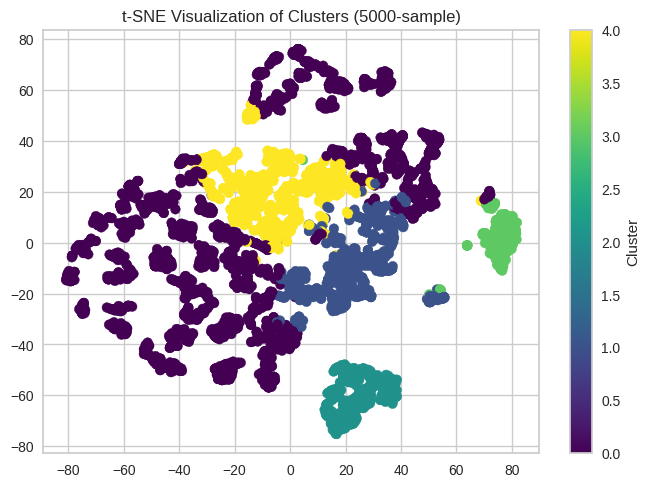

In [ ]:
from sklearn.manifold import TSNE

df_sample=df_scaled.sample(n=5000,random_state=42)
tsne = TSNE(n_components=2, init='pca', random_state=0)
X_tsne = tsne.fit_transform(df_sample.drop(columns='labels'))

sc = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df_sample['labels'],cmap='viridis')
plt.colorbar(sc, label="Cluster")
plt.title("t-SNE Visualization of Clusters (5000-sample)")
plt.show()



*   The t-SNE visualization on a 5,000-sample subset shows distinguishable cluster structures with partial overlap between some regions, which can be expected in real salary based datasets where boundaries are not perfect.



In [ ]:
df_scaled['labels'].value_counts(normalize=True).map(lambda x: round(x*100,2))

,proportion
labels,
0,54.79
1,16.29
5,13.77
2,8.38
3,5.53
4,1.24




*   Cluster size analysis reveals that Cluster 5 contains the majority of learners (38.25%), indicating a dominant segment representing standard career progression patterns. Clusters 0 and 4 also account for significant proportions, suggesting multiple mid-level groups with varying salary–experience ratios. Smaller clusters such as Cluster 2 and Cluster 3 (8.39% and 5.63%, respectively) represent distinct specialized learner categories. The variation in cluster sizes confirms that the dataset contains meaningful natural segmentation rather than random uniform structure.




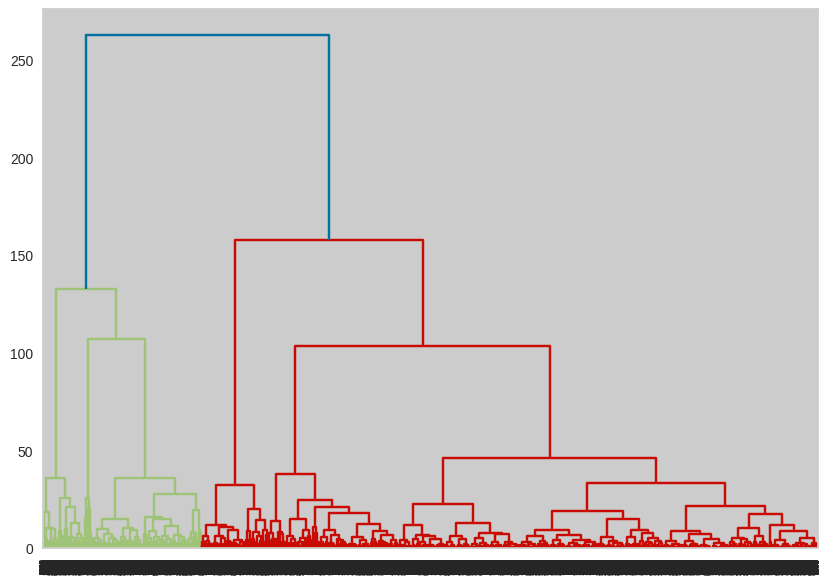

In [ ]:
#Hierarchical Clustering:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

df_sampled = df_scaled.sample(n=10000, random_state=42)
Z = linkage(df_sampled, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.show()

In [ ]:
scaled_df_aglo=df_scaled.copy()
scaled_df_aglo=scaled_df_aglo.sample(n=5000, random_state=42)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=5, linkage = 'ward')
y_pred = model.fit_predict(scaled_df_aglo)

scaled_df_aglo['labels_aglo']=y_pred
scaled_df_aglo.drop(columns='labels')

,company_hash,job_position,experience,ctc_capped,no_of_ctc_update,labels_aglo
51334,-1.485000,-0.370293,0.000000,-0.330777,-0.306101,0
16513,0.094755,-0.370293,-0.213950,0.028073,-0.306101,0
129519,0.032550,0.257081,-0.712743,-0.144867,-0.306101,0
146578,-0.136021,-0.370293,0.000000,-0.144867,-0.306101,0
59301,-0.241400,2.737098,0.534241,-0.326453,-0.306101,1
...,...,...,...,...,...,...
124949,0.239570,0.257081,-0.962140,1.757468,-0.306101,3
30178,1.847474,-0.370293,-0.962140,0.287482,-0.306101,3
74790,-0.994085,-0.244021,-0.712743,-0.490746,-0.306101,0
60460,0.295765,0.189727,-1.211537,0.157777,-0.306101,0


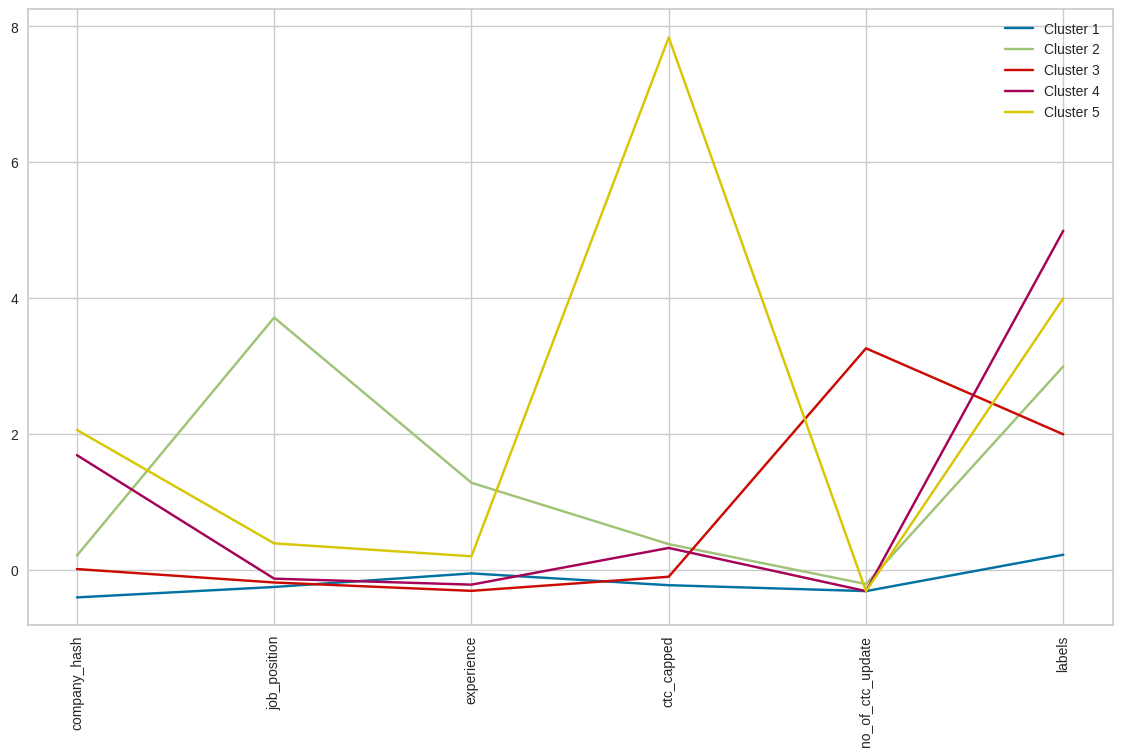

In [ ]:
clustered_df = scaled_df_aglo.groupby('labels_aglo').mean()
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']
plt.figure(figsize=(14,8))
plt.plot(clustered_df.T, label=labels)
plt.xticks(rotation=90)
plt.legend(labels)



*   Cluster 2 has High-paying skilled senior roles cluster.
*   Cluster 5 has likely fast salary growth group, due to the number of ctc updates are peaked.


*   Cluster 3 has experience as nominal/average, can be freshers or low salary clusters.
*   Cluster 4 has the weakest trend, showing they are Low-skilled and low paying segment.


*  Cluster 1 includes employees from a large number of companies, indicating that this group represents a widespread category of stable mid-career professionals with similar job roles and compensation patterns across organizations








In [ ]:
# KMeans profile
kmeans_profile = df_sample.groupby('labels')[['experience','ctc_capped']].mean()

# Hierarchical profile (assuming hierarchy labels stored as 'h_labels')
hier_profile = scaled_df_aglo.groupby('labels_aglo')[['experience','ctc_capped']].mean()

In [ ]:
kmeans_profile

,experience,ctc_capped
labels,,
0,-0.440855,-0.296452
1,-0.192961,0.847892
2,-0.302393,-0.095082
3,1.292345,0.551861
4,1.286021,0.040684


In [ ]:
hier_profile

,experience,ctc_capped
labels_aglo,,
0,-0.045812,-0.219328
1,1.287438,0.384709
2,-0.302393,-0.095082
3,-0.211211,0.328704
4,0.206109,7.838627




*  Both clustering methods identified similar learner segments even though the numerical cluster labels differ. The patterns in experience and salary progression were consistent across both methods. K-Means provided slightly finer segmentation, especially distinguishing between junior-level subgroups, whereas hierarchical clustering produced more aggregated cluster structures. Despite labeling differences, the fundamental segment definitions align across both approaches.




In [ ]:
s=df1['company_hash'].value_counts()
s.sort_values(ascending=False).head(5)

,count
company_hash,
nvnv wgzohrnvzwj otqcxwto,5437
xzegojo,3595
vbvkgz,2621
zgn vuurxwvmrt vwwghzn,2333
wgszxkvzn,2240


#Insights:


*   Freshers (0–3 years) are significantly underpaid compared to industry medians, but quickly accelerate after 4–6 years.

*   Employees with (5–20) years of experience show the steepest salary growth, indicating skill-based career progression

*   Beyond 20 years, salary growth becomes inconsistent and role-dependent.

*   High salary outliers exist even with low experience.

*   whmxw rgsxwo uqxcvnt rxbxnta is the company hash which has the highest ctc.

*   There weere invalid dates/years in the original data, they had to be modifed based on domain knowledge and extereme values like 119 years of experience were capped, while ctc was also capped (confirming the presence of outliers).
*   Backend Engineer job postion were the highest in the data (count).


*   Manual Clustering and its observations/patterns have been recorded using a Cross-Tabulation Analysis. (in the above code of Manual Clustering).


*   Model based Clustering was also done with their observation recorded, also Hopkins Statistic: 0.98 has confirmed that there is a strong cluster structure.


*   Both clustering methods identified similar learner segments even though the numerical cluster labels differ. The patterns in experience and salary progression were consistent across both methods. K-Means provided slightly finer segmentation, especially distinguishing between junior-level subgroups, whereas hierarchical clustering produced more aggregated cluster structures. Despite labeling differences, the fundamental segment definitions align across both approaches.


*   The model identified five learner groups: freshers with low salary (Cluster 0), accelerated high-growth professionals (Cluster 1), standard early-career workers (Cluster 2), high-earning experienced professionals (Cluster 3), and experienced talent with stagnant salaries (Cluster 4).


*   Cluster visualization (TSNE scatter plot, Dendogram and trend visualization ) shows clear learner segmentation.



Recommendations:




  Learner-Focused Recommendations:



    1. Cluster 0  have  low salary and low experience, cater programs/courses so they can skill-up with projects to contribute towards experience which can lead to higher salary as proved.
    2. Upgrade stagnant cluster of 4 where the salary is avaerage (can be upskilled).
    3. Cluster 3 can be used to be a part of the teaching faculty (if interested) and can also be helpful for peer to peer connetions for jobs in the future, while Cluster 1 would be at a high package already, the goal would be to improve their portfolio (cater courses based on this).




  Employer & Partnership Recommendations:




    1.Identify companies paying below market standards and offer Scaler-trained talent as a competitive advantage.
    2.Build alumni-company matching based on skill gaps identified across clusters.
    3.Create and Elite and job ready pool for companies from Clusters 3,4.
    4.Tie-ups with major companies would also help with the growth of the employer's company as well as Scaler.




  Platform & Product Strategy Recommendations:




    1.Post identification of cluster bases customers, personalise content recommendations, projects, intermships etc.
    2.Proof of salary progression post course completion advertised to new learners.
    3.Drawing a Clear Roap Map for the entire course-work.




